# Superstore Sales Analytics — Exploratory Analysis

**Dataset:** [Superstore Sales Dataset](https://www.kaggle.com/datasets/aditisaxena20/superstore-sales-dataset) (Kaggle, *aditisaxena20*) — 51,290 order lines from a global retailer, 2011–2014, across 147 countries and 7 markets.

This notebook works through three business questions:

1. **Regional & category performance** — where does revenue and profit actually come from?
2. **Discount–profit efficiency** — at what point does discounting destroy margin?
3. **Sales trends & seasonality** — how is the business growing, and when does it peak?

The cleaning and aggregation logic lives in `/src` and is imported here, so the notebook and the
Streamlit dashboard are guaranteed to produce the same numbers.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

# Make the project's /src package importable regardless of where Jupyter started.
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(PROJECT_ROOT))

from src import analysis as an
from src import config
from src.data_cleaning import clean_orders
from src.data_loader import describe_raw_data, load_raw_data

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Shared colours so every chart reads consistently.
C_REVENUE, C_PROFIT, C_LOSS = "#2E5EAA", "#2A9D8F", "#D1495B"


def thousands(ax, axis="y"):
    """Format an axis in thousands with a $ prefix."""
    fmt = mticker.FuncFormatter(lambda v, _: f"${v/1_000:,.0f}k")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)

## 2. Data quality audit

Before any analysis, understand what the raw file actually contains.

In [2]:
raw = load_raw_data()
print(f"Rows: {raw.shape[0]:,}   Columns: {raw.shape[1]}")
raw.head()

Rows: 51,290   Columns: 21


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,01-01-2011,06-01-2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.00,106.14,35.46,Medium,2011
1,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.10,36.04,9.72,Medium,2011
2,HU-2011-1220,01-01-2011,05-01-2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.00,29.64,8.17,High,2011
3,IT-2011-3647632,01-01-2011,05-01-2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.50,-26.05,4.82,High,2011
4,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.10,37.77,4.70,Medium,2011


In [3]:
describe_raw_data(raw)

,dtype,missing,missing_pct,unique,example
order_id,str,0,0.00,25035,AG-2011-2040
order_date,str,0,0.00,1430,01-01-2011
ship_date,str,0,0.00,1464,06-01-2011
ship_mode,str,0,0.00,4,Standard Class
customer_name,str,0,0.00,795,Toby Braunhardt
segment,str,0,0.00,3,Consumer
state,str,0,0.00,1094,Constantine
country,str,0,0.00,147,Algeria
market,str,0,0.00,7,Africa
region,str,0,0.00,13,Africa


### What the audit reveals

The file is clean on the surface — **no missing values in any column** — but it hides four traps that
would quietly corrupt the analysis:

| # | Issue | Consequence if ignored |
|---|-------|------------------------|
| 1 | File is **Latin-1 encoded**, not UTF-8 | `read_csv` raises `UnicodeDecodeError` on accented names |
| 2 | `sales` and `shipping_cost` load as **text** — thousands separators (`"1,275"`) and padding (`" 35.46 "`) | Revenue cannot be summed; silent `TypeError` on comparison |
| 3 | Dates are **day-first** (`06-01-2011` = 6 January) | Default parsing swaps day/month for the first 12 days of every month |
| 4 | `region` values are **only unique within a market** | `groupby("region")` merges US Central, EU Central and LATAM Central |

Let's confirm each one rather than take it on faith.

In [4]:
# Trap 2: how many sales values are not plain integers?
non_numeric = raw[config.COL_SALES].astype(str).str.contains(",").sum()
print(f"`sales` values containing a thousands separator: {non_numeric:,}")
print(f"`sales` dtype as loaded: {raw[config.COL_SALES].dtype}")
print(f"`shipping_cost` raw sample: {raw[config.COL_SHIPPING_COST].head(3).tolist()}")

# Trap 4: the same region name under several markets.
overlap = raw.groupby(config.COL_REGION)[config.COL_MARKET].nunique()
print("\nRegion names shared across multiple markets:")
print(overlap[overlap > 1].to_string())

`sales` values containing a thousands separator: 2,630
`sales` dtype as loaded: str
`shipping_cost` raw sample: [35.46, 9.72, 8.17]

Region names shared across multiple markets:
region
Central    3
North      2
South      3


In [5]:
# Duplicates: no identical rows, but repeated product lines within an order.
print(f"Fully duplicated rows:            {raw.duplicated().sum():,}")
print(f"Duplicated (order_id, product_id): {raw.duplicated(subset=config.ORDER_LINE_KEY).sum():,}")

Fully duplicated rows:            0
Duplicated (order_id, product_id): 38


> **Insight.** A dataset with zero nulls is not a clean dataset. The real defects here are *type* and
> *semantic* defects — a text revenue column and an ambiguous grouping key. Both pass a null check and
> both produce plausible-looking but wrong answers.

## 3. Cleaning

`clean_orders()` applies the fixes above and derives the analysis columns.

In [6]:
df = clean_orders(raw)

print(f"Rows before cleaning: {len(raw):,}")
print(f"Rows after cleaning:  {len(df):,}  ({len(raw) - len(df)} duplicate order lines removed)")
print(f"Date range: {df[config.COL_ORDER_DATE].min():%d %b %Y} to {df[config.COL_ORDER_DATE].max():%d %b %Y}")
print(f"\nDerived columns: {[c for c in df.columns if c not in raw.columns]}")
df[[config.COL_ORDER_DATE, config.COL_SALES, config.COL_PROFIT,
    config.COL_PROFIT_MARGIN, config.COL_DISCOUNT_BAND, config.COL_MARKET_REGION]].head()

Rows before cleaning: 51,290
Rows after cleaning:  51,252  (38 duplicate order lines removed)
Date range: 01 Jan 2011 to 31 Dec 2014

Derived columns: ['quarter', 'month', 'month_name', 'year_month', 'profit_margin', 'is_loss', 'shipping_days', 'discount_band', 'market_region']


,order_date,sales,profit,profit_margin,discount_band,market_region
0,2011-01-01,408.00,106.14,0.26,0%,Africa - Africa
1,2011-01-01,120.00,36.04,0.30,1-10%,APAC - Oceania
2,2011-01-01,66.00,29.64,0.45,0%,EMEA - EMEA
3,2011-01-01,45.00,-26.05,-0.58,31-50%,EU - North
4,2011-01-01,114.00,37.77,0.33,1-10%,APAC - Oceania


In [7]:
kpis = an.calculate_kpis(df)
print(f"Revenue           ${kpis['revenue']:,.0f}")
print(f"Profit            ${kpis['profit']:,.0f}")
print(f"Profit margin      {kpis['profit_margin']:.1%}")
print(f"Orders             {kpis['orders']:,}")
print(f"Average discount   {kpis['avg_discount']:.1%}")
print(f"Loss-making lines  {kpis['loss_making_share']:.1%}")

Revenue           $12,633,600
Profit            $1,466,649
Profit margin      11.6%
Orders             25,035
Average discount   14.3%
Loss-making lines  24.5%


> **Insight.** The business turns **$12.6M of revenue into $1.47M of profit (11.6% margin)** — but
> **24.5% of all order lines lose money**. Roughly one line in four is sold at a loss, which frames
> the discount question in section 5.

---
## 4. Question 1 — Regional & category performance

*Which regions, categories and sub-categories drive revenue and profit?*

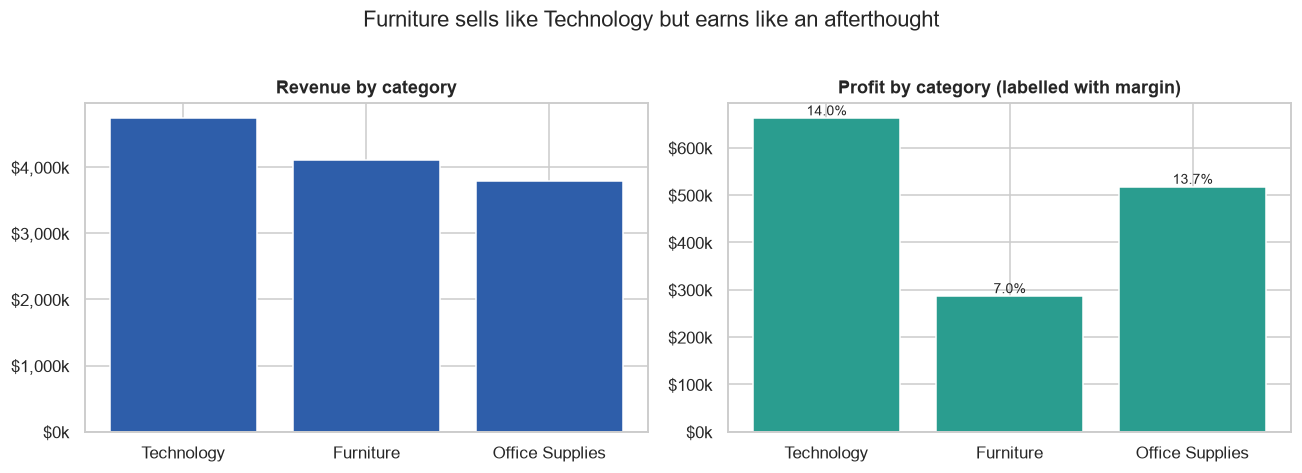

,category,revenue,profit,units,avg_discount,orders,profit_margin
0,Technology,"4,740,555.00","662,370.22",35155,0.14,8354,0.14
1,Furniture,"4,109,132.00","286,631.12",34939,0.17,8195,0.07
2,Office Supplies,"3,783,913.00","517,647.36",108111,0.14,19003,0.14


In [8]:
category = an.performance_by_category(df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

cat_sorted = category.sort_values("revenue", ascending=False)
axes[0].bar(cat_sorted[config.COL_CATEGORY], cat_sorted["revenue"], color=C_REVENUE)
axes[0].set_title("Revenue by category")
thousands(axes[0])

axes[1].bar(cat_sorted[config.COL_CATEGORY], cat_sorted["profit"], color=C_PROFIT)
for i, (_, r) in enumerate(cat_sorted.iterrows()):
    axes[1].text(i, r["profit"], f"{r['profit_margin']:.1%}", ha="center", va="bottom", fontsize=9)
axes[1].set_title("Profit by category (labelled with margin)")
thousands(axes[1])

fig.suptitle("Furniture sells like Technology but earns like an afterthought", y=1.02)
plt.tight_layout()
plt.show()

category

> **Insight.** The three categories look evenly matched on revenue — Technology $4.74M, Furniture
> $4.11M, Office Supplies $3.78M — but profit tells a completely different story. Furniture generates
> **almost as much revenue as Technology yet less than half the profit** ($287k vs $662k), a **7.0%
> margin against 14.0%**. Office Supplies quietly earns more profit than Furniture from $325k *less*
> revenue. Revenue rankings alone would have pointed management at the wrong category.

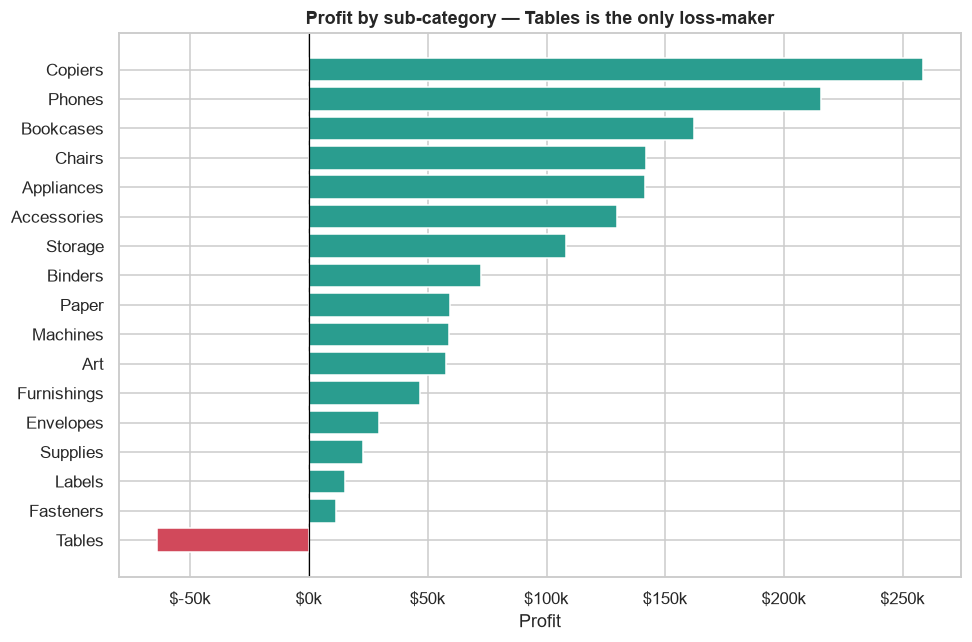

,category,sub_category,revenue,profit,profit_margin,avg_discount
7,Furniture,Tables,"757,034.00","-64,083.39",-0.08,0.29
15,Office Supplies,Fasteners,"83,254.00","11,525.42",0.14,0.14
16,Office Supplies,Labels,"73,422.00","15,004.96",0.20,0.12


In [9]:
sub = an.performance_by_sub_category(df).sort_values("profit")
colors = [C_LOSS if p < 0 else C_PROFIT for p in sub["profit"]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(sub[config.COL_SUB_CATEGORY], sub["profit"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Profit by sub-category — Tables is the only loss-maker")
ax.set_xlabel("Profit")
thousands(ax, axis="x")
plt.tight_layout()
plt.show()

sub.head(3)[[config.COL_CATEGORY, config.COL_SUB_CATEGORY, "revenue", "profit",
             "profit_margin", "avg_discount"]]

> **Insight.** **Tables is the only sub-category that loses money outright: -$64k on $757k of revenue
> (-8.5% margin)** — and it carries the highest average discount of any sub-category at **29.1%**, more
> than double the company average of 14.3%. Bookcases and Machines are the next weakest. Because Tables
> and Bookcases both sit inside Furniture, they explain most of that category's margin gap.

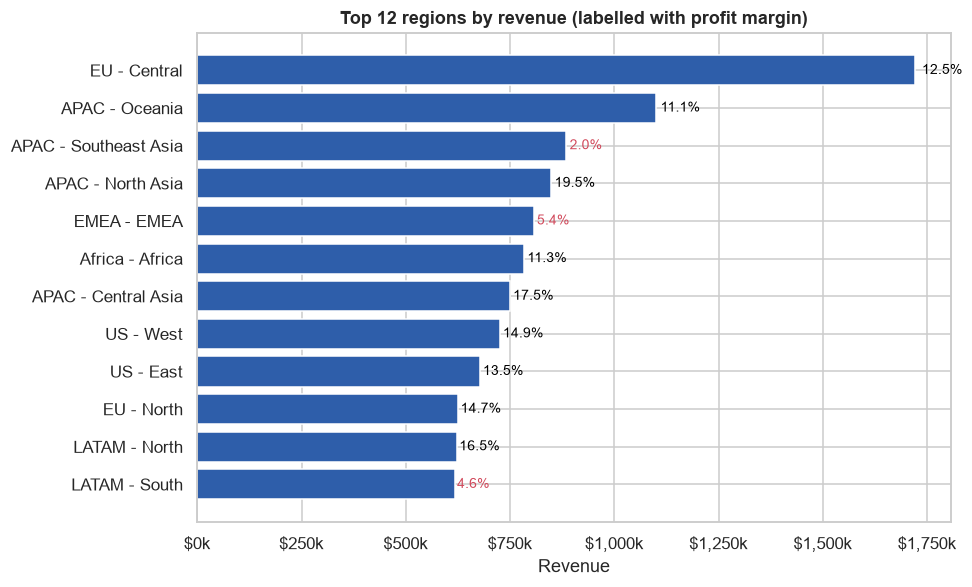

In [10]:
region = an.performance_by_region(df).head(12).sort_values("revenue")

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(region[config.COL_MARKET_REGION], region["revenue"], color=C_REVENUE)
for bar, margin in zip(bars, region["profit_margin"]):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            f"{margin:.1%}", va="center", fontsize=9,
            color=C_LOSS if margin < 0.06 else "black")
ax.set_title("Top 12 regions by revenue (labelled with profit margin)")
ax.set_xlabel("Revenue")
thousands(ax, axis="x")
plt.tight_layout()
plt.show()

> **Insight.** **EU–Central is the single largest region at $1.72M** and healthily profitable at 12.5%.
> The interesting cases are the outliers: **APAC–Southeast Asia turns $884k of revenue into just 2.0%
> margin**, and EMEA manages only 5.4% — both well below the 11.6% company average. Meanwhile
> **APAC–North Asia and APAC–Central Asia deliver 19.5% and 17.5% margins** on smaller volumes. Growth
> capital is better spent in North Asia than Southeast Asia.
>
> Note these are *market-qualified* regions. Grouping on the raw `region` column would have collapsed
> the three separate "Central" territories into one meaningless aggregate.

---
## 5. Question 2 — Discount–profit efficiency

*How does discounting affect margin, and what is being over-discounted to the point of loss?*

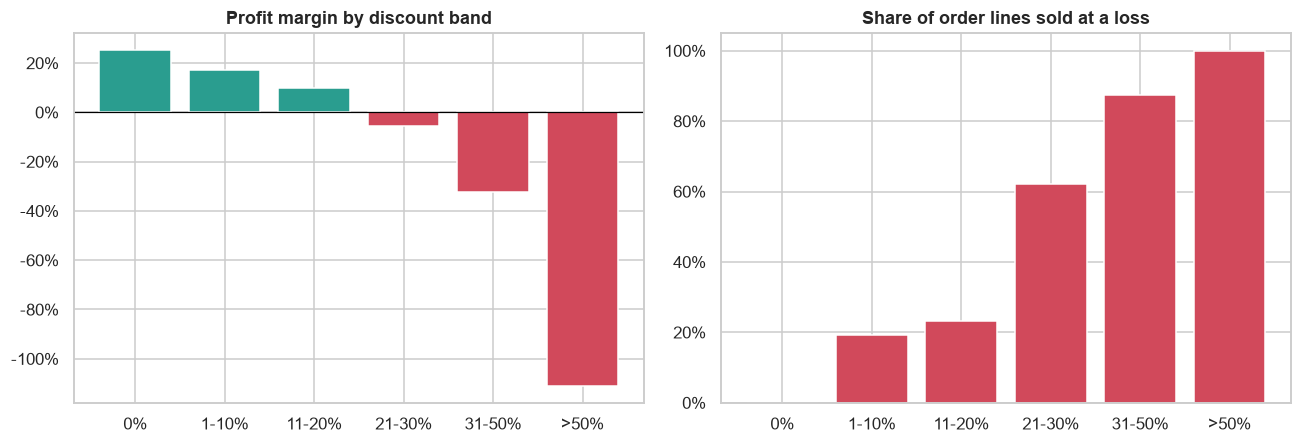

Correlation between discount rate and profit margin: -0.85
Aggregate profit turns negative from the 20% discount band onward.


,discount_band,revenue,profit,order_lines,loss_making_share,profit_margin
0,0%,"6,985,692.00","1,768,725.09",28983,0.00,0.25
1,1-10%,"1,961,502.00","339,445.02",4673,0.19,0.17
2,11-20%,"1,756,847.00","173,196.31",6271,0.23,0.10
3,21-30%,"381,915.00","-21,232.98",965,0.62,-0.06
4,31-50%,"1,176,020.00","-380,903.09",6188,0.87,-0.32
5,>50%,"371,624.00","-412,581.66",4172,1.00,-1.11


In [11]:
bands = an.discount_band_summary(df)
correlation = an.discount_profit_correlation(df)
break_even = an.break_even_discount(df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

colors = [C_LOSS if m < 0 else C_PROFIT for m in bands["profit_margin"]]
axes[0].bar(bands[config.COL_DISCOUNT_BAND].astype(str), bands["profit_margin"], color=colors)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Profit margin by discount band")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))

axes[1].bar(bands[config.COL_DISCOUNT_BAND].astype(str), bands["loss_making_share"], color=C_LOSS)
axes[1].set_title("Share of order lines sold at a loss")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))

plt.tight_layout()
plt.show()

print(f"Correlation between discount rate and profit margin: {correlation:.2f}")
print(f"Aggregate profit turns negative from the {break_even:.0%} discount band onward.")
bands

> **Insight.** The relationship is close to linear and strongly negative — **correlation of -0.85
> between discount rate and profit margin**. Margin falls from **+25.3% on undiscounted lines to
> +9.9% at 11–20%, then flips to -5.6% at 21–30% and collapses to -111% above 50%**.
>
> **The break-even point is a 20% discount.** Below it the business is profitable; above it, it is not.
> The loss-rate chart is even starker: **no undiscounted line loses money, 62% of lines lose money in
> the 21–30% band, and above 50% every single line does — 100%, without exception.** Discounts beyond
> 50% are not a pricing strategy, they are a guaranteed loss.

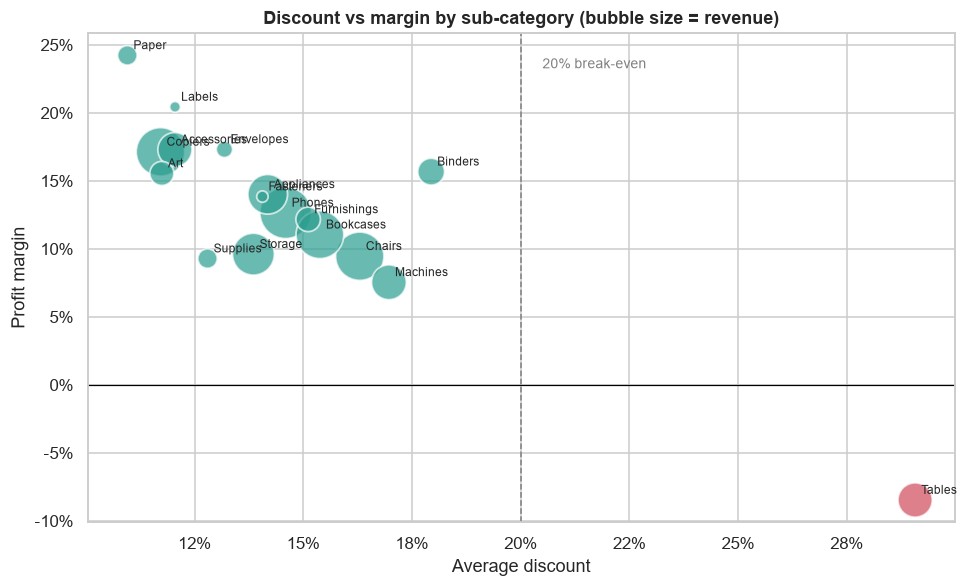

In [12]:
scatter = an.discount_vs_margin_scatter(df)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(scatter["avg_discount"], scatter["profit_margin"],
           s=scatter["revenue"] / 1_500,
           c=[C_LOSS if m < 0 else C_PROFIT for m in scatter["profit_margin"]],
           alpha=0.7, edgecolor="white", linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0.20, color="grey", linestyle="--", linewidth=1)
ax.text(0.205, ax.get_ylim()[1] * 0.9, "20% break-even", fontsize=9, color="grey")

for _, r in scatter.iterrows():
    ax.annotate(r[config.COL_SUB_CATEGORY], (r["avg_discount"], r["profit_margin"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("Average discount")
ax.set_ylabel("Profit margin")
ax.set_title("Discount vs margin by sub-category (bubble size = revenue)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout()
plt.show()

> **Insight.** Every sub-category sits below a clear downward diagonal — and **Tables is the only one
> pushed past the 20% break-even line into negative margin**. It is not that Tables is an inherently
> bad product; it is the only sub-category being discounted at a rate the category's margin cannot
> absorb. Paper and Labels sit at the opposite corner: low discount, ~20–24% margin.

In [13]:
worst_products = an.over_discounted_groups(df, by=config.COL_PRODUCT_NAME, min_orders=20, top_n=10)
worst_products[[config.COL_PRODUCT_NAME, "revenue", "profit", "profit_margin",
                "avg_discount", "orders"]]

,product_name,revenue,profit,profit_margin,avg_discount,orders
0,"Motorola Smart Phone, Cordless","38,935.00","-4,447.04",-0.11,0.12,23
1,"Rogers Lockers, Blue","28,215.00","-2,893.49",-0.10,0.14,42
2,"Eldon Lockers, Blue","19,254.00","-2,181.10",-0.11,0.20,36
3,"Samsung Audio Dock, with Caller ID","7,663.00","-2,137.22",-0.28,0.12,20
4,"SAFCO Executive Leather Armchair, Red","25,024.00","-1,845.45",-0.07,0.17,20
5,"Office Star Swivel Stool, Adjustable","14,250.00","-1,673.24",-0.12,0.16,30
6,"Harbour Creations Rocking Chair, Set of Two","7,299.00","-1,478.00",-0.20,0.24,20
7,"Logitech Router, Bluetooth","12,268.00","-1,415.64",-0.12,0.18,21
8,"Smead File Cart, Blue","12,836.00","-1,381.00",-0.11,0.20,42
9,"Samsung Smart Phone, Cordless","45,459.00","-1,348.29",-0.03,0.13,25


> **Insight.** Drilling to individual products refines the story rather than confirming it. Each of
> these SKUs loses money across **20+ separate orders**, so they are systematic failures, not one-off
> bad deals — but their average discounts sit at **12–24%, mostly at or below the 20% break-even line**.
> **Discounting alone does not explain them.** *Motorola Smart Phone, Cordless* loses $4.4k at just a
> **12% average discount**, which points to a cost or list-price problem, not an over-discounting one.
>
> So there are two distinct failure modes needing two different fixes: a **discount ceiling** for the
> Tables-type cases, and a **pricing or sourcing review** for these structurally unprofitable SKUs.

---
## 6. Question 3 — Sales trends & seasonality

*How do sales and profit trend over time, and are there seasonal patterns?*

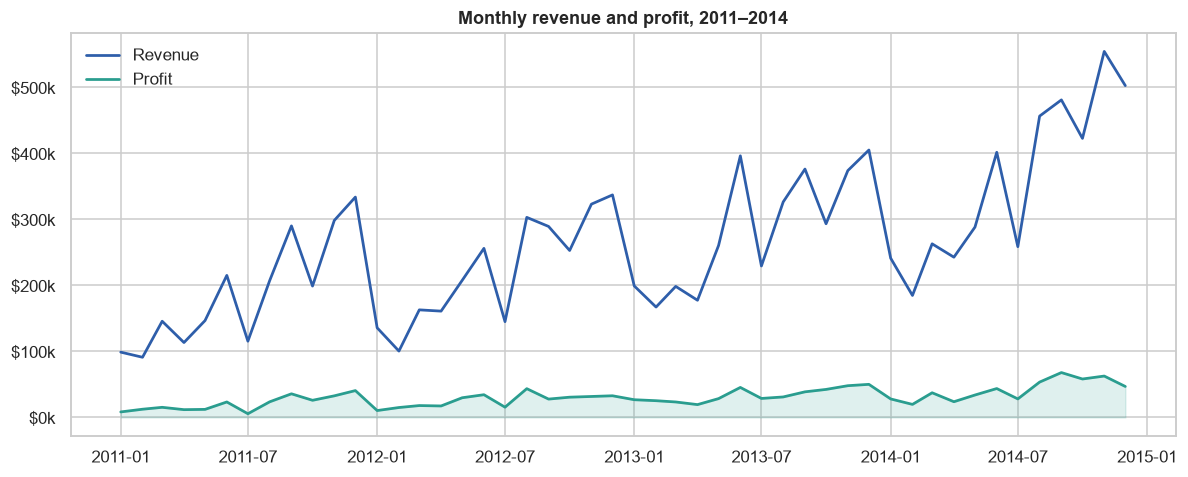

In [14]:
monthly = an.monthly_trend(df)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly[config.COL_YEAR_MONTH], monthly["revenue"], color=C_REVENUE, label="Revenue", linewidth=1.8)
ax.plot(monthly[config.COL_YEAR_MONTH], monthly["profit"], color=C_PROFIT, label="Profit", linewidth=1.8)
ax.fill_between(monthly[config.COL_YEAR_MONTH], monthly["profit"], color=C_PROFIT, alpha=0.15)
ax.set_title("Monthly revenue and profit, 2011–2014")
ax.legend(frameon=False)
thousands(ax)
plt.tight_layout()
plt.show()

In [15]:
yearly = an.yearly_trend(df)
yearly[[config.COL_YEAR, "revenue", "profit", "profit_margin", "orders", "revenue_growth"]]

,year,revenue,profit,profit_margin,orders,revenue_growth
0,2011,"2,255,667.00","247,727.98",0.11,4440,NaN
1,2012,"2,675,016.00","306,990.49",0.11,5343,0.19
2,2013,"3,404,334.00","408,055.30",0.12,6721,0.27
3,2014,"4,298,583.00","503,874.92",0.12,8531,0.26


> **Insight.** The business is **growing strongly and consistently — revenue nearly doubled from $2.26M
> in 2011 to $4.30M in 2014**, compounding at roughly **25% a year** (+18.6%, +27.3%, +26.3%). Crucially,
> **margin held steady at 11–12% throughout**, so this is genuine growth rather than volume bought with
> discounts. The month-to-month series is highly volatile, which points to seasonality worth isolating.

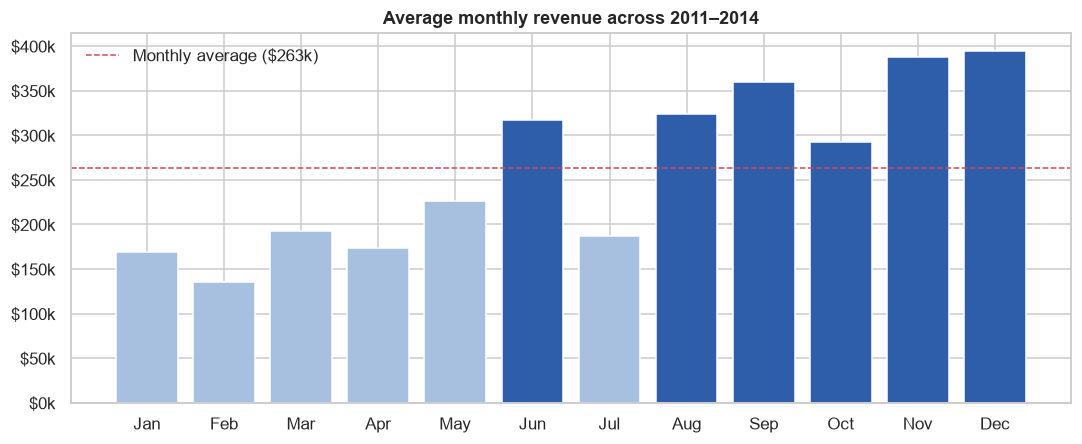

In [16]:
seasonal = an.seasonality_by_month(df)
overall_mean = seasonal["avg_revenue"].mean()

fig, ax = plt.subplots(figsize=(10, 4.2))
colors = [C_REVENUE if v >= overall_mean else "#A8C0E0" for v in seasonal["avg_revenue"]]
ax.bar(seasonal[config.COL_MONTH_NAME].astype(str), seasonal["avg_revenue"], color=colors)
ax.axhline(overall_mean, color=C_LOSS, linestyle="--", linewidth=1,
           label=f"Monthly average (${overall_mean/1_000:,.0f}k)")
ax.set_title("Average monthly revenue across 2011–2014")
ax.legend(frameon=False)
thousands(ax)
plt.tight_layout()
plt.show()

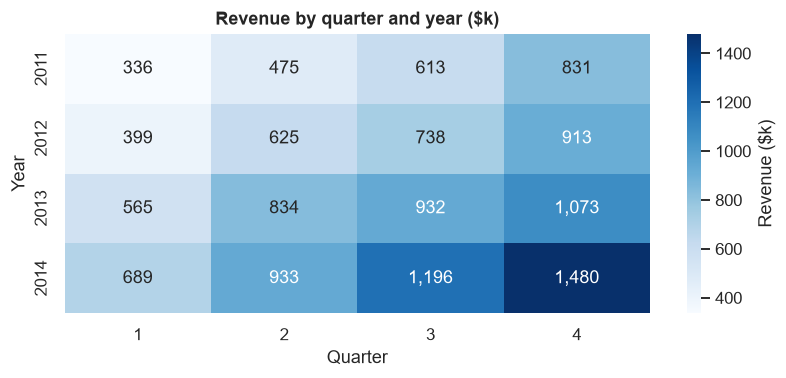

In [17]:
quarterly = an.quarterly_summary(df)
pivot = quarterly.pivot(index=config.COL_YEAR, columns=config.COL_QUARTER, values="revenue")

fig, ax = plt.subplots(figsize=(7.5, 3.6))
sns.heatmap(pivot / 1_000, annot=True, fmt=",.0f", cmap="Blues", cbar_kws={"label": "Revenue ($k)"}, ax=ax)
ax.set_title("Revenue by quarter and year ($k)")
ax.set_xlabel("Quarter")
ax.set_ylabel("Year")
plt.tight_layout()
plt.show()

> **Insight.** Seasonality is pronounced and repeats every year. **Q4 is consistently the strongest
> quarter, with November ($388k) and December ($395k) the peak months**, running roughly **50% above
> the $263k monthly average**. **February is the annual trough at $136k — barely a third of December.**
> September is a secondary peak ($359k).
>
> The pattern holds in all four years, so it is structural rather than noise. Practically: inventory and
> staffing should be planned around an **H2-weighted year**, and the Q1 lull is the natural window for
> clearing stock — ideally with the discount ceiling from section 5 enforced.

---
## 7. Conclusions & recommendations

| # | Finding | Recommended action |
|---|---------|--------------------|
| 1 | Furniture earns a **7.0% margin vs Technology's 14.0%** on near-identical revenue | Review Furniture pricing and cost base before chasing more Furniture volume |
| 2 | **Discounts above 20% are loss-making**; correlation of **-0.85**; **100% of lines above 50% lose money** | Enforce a hard 20% discount ceiling, with sign-off required above it |
| 3 | **Tables is the only loss-making sub-category** (-$64k, -8.5%) and the most discounted (29.1%) | Re-price Tables or withdraw the worst SKUs; a full margin recovery is worth ~$64k+ |
| 4 | Revenue is **compounding ~25% a year at a stable margin**, with a **Q4 peak ~50% above average** and a February trough | Plan inventory and staffing to an H2-weighted year; use Q1 for controlled clearance |

**The headline:** the growth story is healthy — this is not a demand problem. The margin leak has two
separate causes that are easy to conflate: **a discounting-discipline problem** (Tables, and every line
sold above 20% off) and **a smaller pricing problem** in a handful of SKUs that lose money even at
modest discounts. A discount ceiling fixes the first but would do nothing for the second.

The cleaning and aggregation functions used above are imported from `/src` and power the Streamlit
dashboard in `/app`, so every figure in this notebook and every figure on the dashboard comes from a
single implementation.